In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import ast
from datasets import load_dataset
import seaborn as sns

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_month'] = pd.to_datetime(df.job_posted_date).dt.strftime('%b')
df = df.dropna(subset=['job_skills'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x))

# Filtering for Job and Country
df_da_us = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')]
df = df.explode('job_skills')


In [2]:
# Filtering Country and Job
df = df[(df['job_country'] == 'United States') & (df['job_title_short'] == 'Data Analyst')].copy()

# Top 5 Skills
top_skills = df['job_skills'].value_counts().head(5).index.tolist()

df_modified =  df[df['job_skills'].isin(top_skills)]
df_modified['job_month_no'] = pd.to_datetime(df_modified['job_posted_date']).dt.month
df_modified.sort_values('job_month_no' ,inplace = True)

skill_trend = df_modified.pivot_table(index = 'job_skills' , columns = 'job_month' , values = 'job_title_short' , aggfunc = 'count')
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

skill_trend = skill_trend[month_order]
skill_trend
for i in range(5):
    for idx ,j in enumerate(month_order):
        total = df_da_us[df_da_us['job_month'] == j]['job_title_short'].count()
        val = skill_trend[j].iloc[i]
        perc = (val/total)*100
        skill_trend.iloc[i , idx] = perc

skill_trend



C:\Users\skuma\AppData\Local\Temp\ipykernel_26504\959408004.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modified['job_month_no'] = pd.to_datetime(df_modified['job_posted_date']).dt.month
C:\Users\skuma\AppData\Local\Temp\ipykernel_26504\959408004.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_modified.sort_values('job_month_no' ,inplace = True)
C:\Users\skuma\AppData\Local\Temp\ipykernel_26504\959408004.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '47.7659

job_month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
job_skills,,,,,,,,,,,,
excel,47.765957,48.940598,49.831461,48.607933,49.198606,48.414634,48.213066,48.551111,46.962190,45.159774,44.759124,47.038865
python,29.973404,30.609156,31.516854,32.017544,31.335656,32.703252,32.733895,36.000000,32.046936,32.260338,30.627737,33.189389
sas,24.361702,22.928490,23.183521,24.828375,22.578397,20.000000,22.672433,22.684444,22.320730,22.556391,23.124088,24.059223
sql,61.183511,59.931896,60.411985,61.403509,59.953542,58.170732,59.389939,60.693333,59.843546,60.479323,59.970803,57.001851
tableau,33.085106,31.706394,33.782772,34.115179,33.263647,33.089431,34.896426,34.684444,35.280313,33.576128,33.518248,33.312770


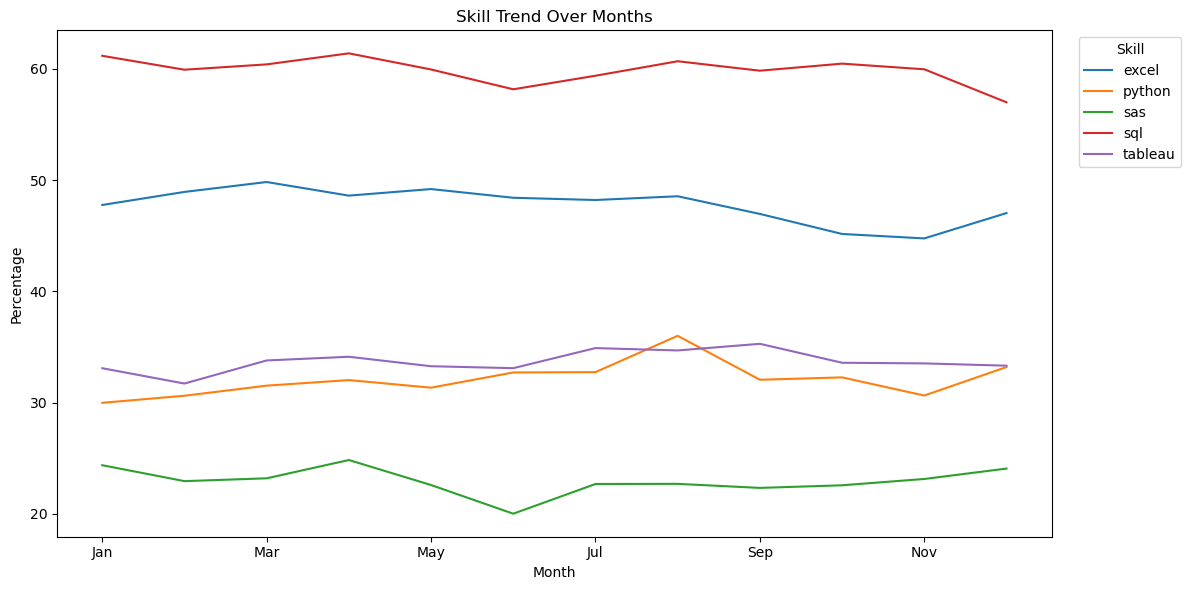

In [3]:
skill_trend.T.plot(kind='line', figsize=(12,6))
plt.xlabel('Month')
plt.ylabel('Percentage')
plt.title('Skill Trend Over Months')
plt.legend(title='Skill', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

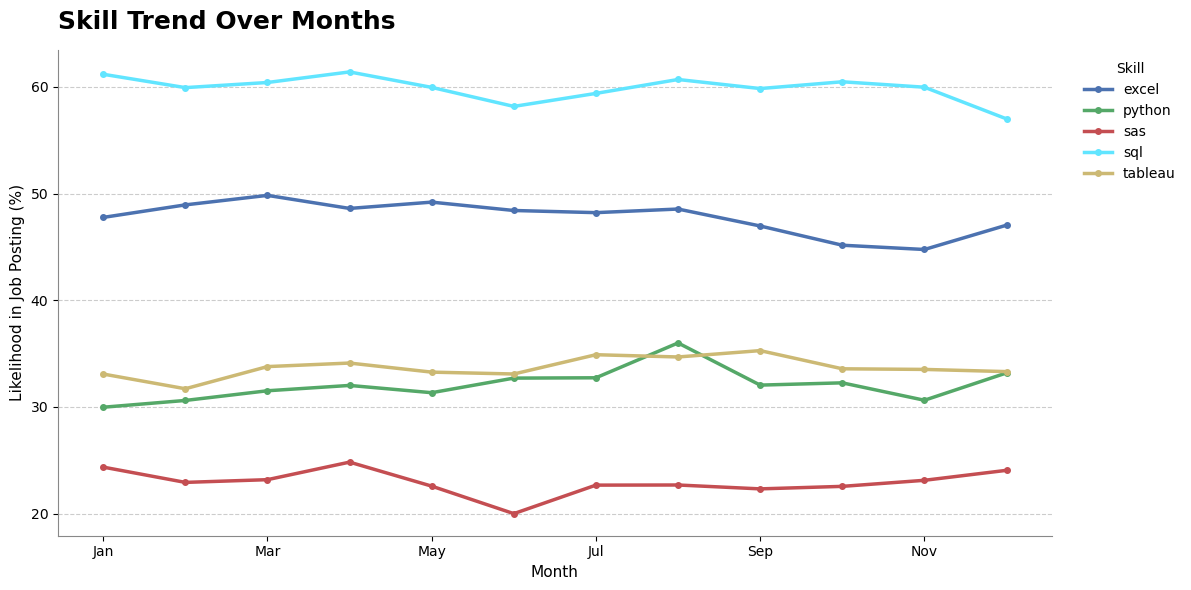

In [4]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']

colors = ['#4C72B0', '#55A868', '#C44E52', "#61E5FF", '#CCB974']

fig, ax = plt.subplots(figsize=(12, 6))

skill_trend.T.plot(kind='line', ax=ax, color=colors, linewidth=2.5, marker='o', markersize=4)

ax.set_title('Skill Trend Over Months', fontsize=18, fontweight='bold', loc='left', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Likelihood in Job Posting (%)', fontsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#888888')
ax.spines['bottom'].set_color('#888888')

ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')
ax.set_axisbelow(True)

ax.legend(title='Skill', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False, fontsize=10)

ax.tick_params(axis='both', labelsize=10)

plt.tight_layout()
plt.show()